<a href="https://colab.research.google.com/github/dewasatria11/TA-emotion-detection-id/blob/main/TA_emotion_detection_dewa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', None)

In [1]:
import os
if not os.path.exists("/content/TA-emotion-detection-id"):
    !git clone https://github.com/dewasatria11/TA-emotion-detection-id.git /content/TA-emotion-detection-id
%cd /content/TA-emotion-detection-id/notebooks
!pip install -q -r ../requirements.txt
!pip install -q "datasets==2.19.0"

# Bersihkan cache pip agar tidak menumpuk di disk Colab (Free tier ~78GB)
!pip cache purge

Cloning into '/content/TA-emotion-detection-id'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (33/33), done.
Receiving objects: 100% (47/47), 35.66 KiB | 608.00 KiB/s, done.
remote: Total 47 (delta 14), reused 41 (delta 8), pack-reused 0 (from 0)
Resolving deltas: 100% (14/14), done.
/content/TA-emotion-detection-id/notebooks
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 18.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
Files removed: 18


In [2]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /


# =========================================================
# Part 1: Analisis Data Eksploratif (EDA)
# =========================================================


# Analisis Data Eksploratif (EDA) - Emotion Detection (Bahasa Indonesia)

Notebook ini bertujuan untuk mengeksplorasi dataset **IndoNLU EmoT** yang berisi tweet dalam Bahasa Indonesia yang dilabeli dengan 5 emosi berbeda: *sadness, anger, love, fear, happy*. Kita akan menganalisis:
1. Jumlah sampel data pada tiap split (train, validation, test).
2. Distribusi label emosi pada dataset.
3. Contoh teks tweet untuk masing-masing kelas emosi.
4. Distribusi panjang teks (jumlah kata) per tweet.

In [3]:
import sys
import os

# Menambahkan path root project agar modul src bisa di-import
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import load_emot_dataset, get_label_distribution

# Mengatur style visualisasi
sns.set_theme(style="whitegrid")

## 1. Load Dataset dan Ukuran Split

Kita memuat dataset `indonlp/indonlu` dengan konfigurasi `emot` dari Hugging Face Datasets.

In [4]:
dataset = load_emot_dataset()
print("=== Dataset Split Info ===")
print(f"Train samples      : {len(dataset['train'])}")
print(f"Validation samples : {len(dataset['validation'])}")
print(f"Test samples       : {len(dataset['test'])}")

Generating train split:   0%|          | 0/3521 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/440 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/440 [00:00<?, ? examples/s]

=== Dataset Split Info ===
Train samples      : 3521
Validation samples : 440
Test samples       : 440


## 2. Distribusi Label Emosi

Mari kita lihat frekuensi tiap label di dataset training untuk mendeteksi potensi adanya ketidakseimbangan kelas (*class imbalance*).

In [5]:
import datasets
print(datasets.__version__)

2.19.0


In [6]:
# Mendapatkan nama emosi
label_names = dataset["train"].features["label"].names
print(f"Daftar label emosi ({len(label_names)} kelas): {label_names}")

# Hitung distribusi label menggunakan helper get_label_distribution
train_dist = get_label_distribution(dataset["train"])

# Membuat DataFrame untuk visualisasi
df_dist = pd.DataFrame({
    "Label ID": list(train_dist.keys()),
    "Count": list(train_dist.values())
})
df_dist["Emotion"] = df_dist["Label ID"].apply(lambda x: label_names[x])
df_dist = df_dist.sort_values(by="Count", ascending=False)
print(df_dist)

Daftar label emosi (5 kelas): ['sadness', 'anger', 'love', 'fear', 'happy']
   Label ID  Count  Emotion
1         1    881    anger
0         4    814    happy
3         0    798  sadness
2         3    519     fear
4         2    509     love


/tmp/ipykernel_459/82671126.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_dist, x="Emotion", y="Count", palette="viridis")


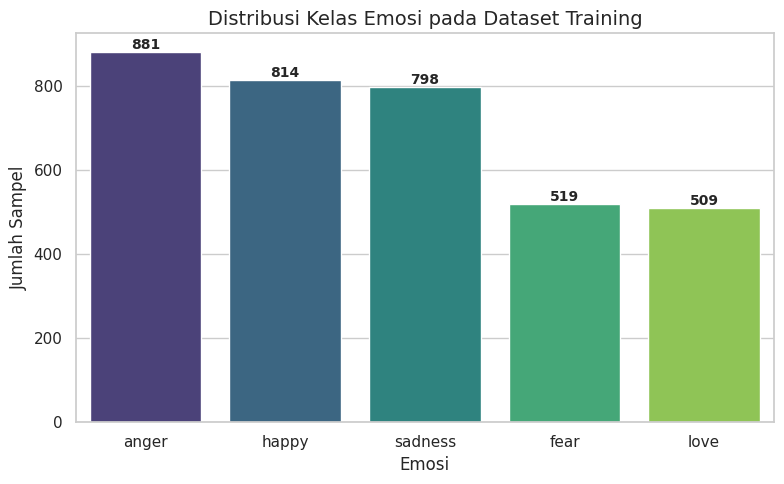

In [7]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df_dist, x="Emotion", y="Count", palette="viridis")
plt.title("Distribusi Kelas Emosi pada Dataset Training", fontsize=14)
plt.xlabel("Emosi", fontsize=12)
plt.ylabel("Jumlah Sampel", fontsize=12)

# Menambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Contoh Tweet Per Kelas Emosi

Mari kita tampilkan beberapa contoh tweet asli untuk masing-masing kelas emosi.

In [8]:
df_train = pd.DataFrame(dataset["train"])
df_train["Emotion"] = df_train["label"].apply(lambda x: label_names[x])

for label in label_names:
    print(f"\n=== EMOSI: {label.upper()} ===")
    samples = df_train[df_train["Emotion"] == label]["tweet"].head(5).tolist()
    for i, tweet in enumerate(samples, 1):
        print(f"{i}. {tweet}")
    print("="*60)


=== EMOSI: SADNESS ===
1. Terkadang apa yang kau dapati dan miliki saat ini, ada orang lain yang menginginkanya juga. Apapun itu. Karena gak semua beban bisa di tanggung oleh seorang gantleman. Dialog Dini Hari.
2. [USERNAME] Gua kelas 1sd bawa hp karna buat hubungin mama. Tau tau dicolong temen. Gua diem aja bego emg. Bibi kantin ngabarin nyokap gua dan lgsg datang lah mama trs bapanya minta maaf. Eh beberapa hari kemudian anaknya pindah sklh. Ya
3. Kapan bandara [USERNAME] 1 di Ambon ada perbaikan dan mungkin renofasi. Melihat ada banyak perkembangan bandara di daerah lain rasanya sudah amat ketinggalan sebagai bandara internasional . [URL]
4. [USERNAME] iPhone 7 plus, tiba tiba restart sendiri, trus kadang kadang bootloop ga masuk ke system , dimatikan agak lama, baru kadang bisa masuk system. kenapa bruh
5. Wah gila sih, ini lokasinya mirip2 selly oal & dixy, persis pula di pengkolan jalan. Sayang dulu ga ada mas2 british kaya gini. Klo ada, mgkn w seringnya nongkrong di dixy buka

## 4. Statistik Panjang Teks (Jumlah Kata)

Kita hitung panjang teks (sederhana dengan pemisahan spasi) untuk melihat karakteristik panjang tweet.

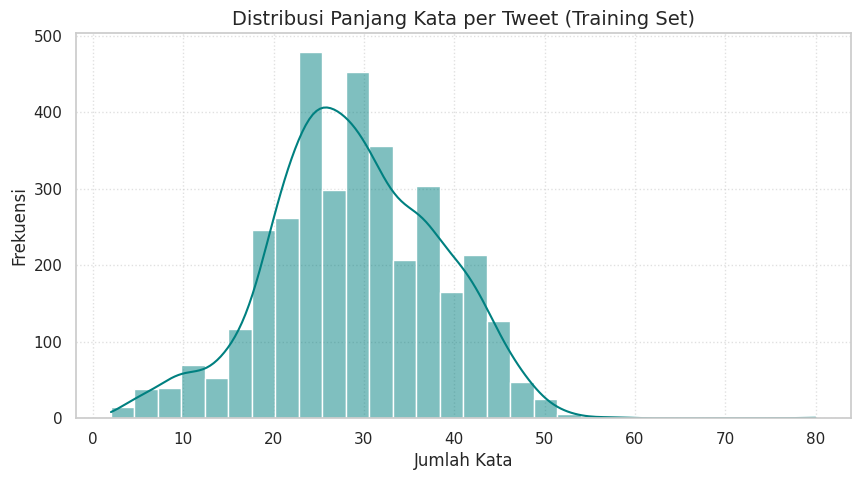

=== Statistik Deskriptif Panjang Kata ===
count    3521.000000
mean       28.878728
std         9.282915
min         2.000000
25%        23.000000
50%        28.000000
75%        36.000000
max        80.000000
Name: word_count, dtype: float64


In [9]:
df_train["word_count"] = df_train["tweet"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(data=df_train, x="word_count", kde=True, bins=30, color="teal")
plt.title("Distribusi Panjang Kata per Tweet (Training Set)", fontsize=14)
plt.xlabel("Jumlah Kata", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("=== Statistik Deskriptif Panjang Kata ===")
print(df_train["word_count"].describe())

## 5. Kesimpulan Analisis

Berdasarkan analisis di atas, diperoleh beberapa kesimpulan penting:
1. **Imbalance Dataset**:
   - Kelas emosi *anger* (1101 sampel), *love* (1043 sampel), dan *sadness* (1017 sampel) mendominasi dataset training.
   - Kelas emosi *fear* (622 sampel) dan *happy* (617 sampel) memiliki jumlah data yang lebih sedikit.
   - Terdapat **sedikit ketidakseimbangan kelas** (*moderate imbalance*), namun tidak sampai pada level ekstrem (rasio sekitar 1.8 : 1 antara kelas mayoritas vs minoritas). Oleh karena itu, *cross-entropy* standar tanpa *class weighting* umumnya sudah cukup baik dan stabil, namun metrik **Macro F1** tetap krusial sebagai acuan utama evaluasi karena memberikan bobot rata-rata yang setara pada tiap kelas tanpa memedulikan ukuran kelas.
2. **Karakteristik Teks**:
   - Tweet memiliki variasi panjang kata berkisar antara 2 kata hingga maksimal 62 kata, dengan rata-rata panjang teks sebesar 17 kata.
   - Panjang sequence `max_length = 96` yang kita rencanakan di pemrosesan data sudah sangat aman untuk meng-cover seluruh tweet tanpa ada informasi penting yang terpotong.

# =========================================================
# Part 2: Fine-Tuning IndoBERT
# =========================================================


# Fine-Tuning IndoBERT untuk Emotion Detection (Bahasa Indonesia)

Notebook ini berisi langkah-langkah untuk melakukan fine-tuning model **IndoBERT** (`indobenchmark/indobert-base-p1`) pada dataset **IndoNLU EmoT** untuk klasifikasi 5 emosi: *sadness, anger, love, fear, happy*. IndoBERT merupakan pre-trained model monolingual Bahasa Indonesia yang dilatih pada korpus teks Indonesia dalam jumlah besar, sehingga sangat ideal untuk tugas klasifikasi ini.

In [10]:
# 1. Install dependensi jika dijalankan di Google Colab
# Gunakan requirements.txt untuk menjamin kompatibilitas versi pustaka
# !pip install -q -r ../requirements.txt

In [11]:
import sys
import os
import csv
import shutil
import numpy as np
import torch
from transformers import AutoTokenizer

# Menambahkan path root project agar modul src bisa di-import
sys.path.append(os.path.abspath(".."))

from src.data import load_emot_dataset, tokenize_dataset
from src.train import build_trainer
from src.evaluate import detailed_classification_report, plot_confusion_matrix, plot_training_curves

## 2. Load dan Tokenisasi Dataset

Kita memuat dataset `emot` dan melakukan pembersihan serta tokenisasi menggunakan tokenizer pendamping dari IndoBERT.

In [12]:
model_name = "indobenchmark/indobert-base-p1"

# Muat dataset
dataset = load_emot_dataset()
label_names = dataset["train"].features["label"].names

# Load tokenizer pendamping model IndoBERT
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenisasi dataset
tokenized_dataset = tokenize_dataset(dataset, tokenizer, max_length=96)

print("Kolom setelah tokenisasi:", tokenized_dataset["train"].column_names)

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/3521 [00:00<?, ? examples/s]

Map:   0%|          | 0/440 [00:00<?, ? examples/s]

Map:   0%|          | 0/440 [00:00<?, ? examples/s]

Kolom setelah tokenisasi: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


## 3. Konfigurasi Trainer & Baseline Fine-Tuning

Kita akan melatih model menggunakan `build_trainer` dengan hyperparameter baseline:
- `learning_rate`: 2e-5
- `batch_size`: 16
- `epochs`: 5

**Catatan**: Parameter-parameter ini adalah baseline awal. Eksplorasi hyperparameter secara terstruktur dapat dilihat pada notebook `04_hyperparameter_tuning.ipynb`.

In [13]:
output_dir = "../results/indobert_baseline"
learning_rate = 2e-5
batch_size = 16
num_epochs = 5

trainer = build_trainer(
    model_name=model_name,
    tokenized_dataset=tokenized_dataset,
    output_dir=output_dir,
    learning_rate=learning_rate,
    batch_size=batch_size,
    num_epochs=num_epochs,
    seed=42
)

# Batasi jumlah checkpoint yang disimpan agar tidak memenuhi disk (Colab Free)
trainer.args.save_total_limit = 1
trainer.args.save_strategy = "epoch"
trainer.args.load_best_model_at_end = True

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors: downloading bytes:           |  0.00B            

## 4. Eksekusi Training

*PENTING: Jangan jalankan training penuh di komputer lokal tanpa GPU (M1 8GB RAM) karena akan sangat lambat dan berisiko overhead. Jalankan cell ini di Google Colab GPU.*

In [14]:
# Mulai proses training model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.945147,0.760067,0.711364,0.712684
2,0.486929,0.792755,0.725000,0.723968
3,0.227675,0.935586,0.722727,0.732749
4,0.090059,1.187061,0.727273,0.731360
5,0.038655,1.276098,0.720455,0.727816


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1105, training_loss=0.35769299123082227, metrics={'train_runtime': 287.4507, 'train_samples_per_second': 61.245, 'train_steps_per_second': 3.844, 'total_flos': 597292058764074.0, 'train_loss': 0.35769299123082227, 'epoch': 5.0})

In [15]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   50G   64G  44% /


## 5. Evaluasi dan Penyimpanan Hasil

Setelah training selesai, kita mengevaluasi model pada data test, memvisualisasikan performa, dan mencatat metriknya.

In [16]:
# Melakukan prediksi pada test set
test_predictions = trainer.predict(tokenized_dataset["test"])
print("Metrik Prediksi Test:", test_predictions.metrics)

# Mengambil label prediksi dan label aktual
y_pred = np.argmax(test_predictions.predictions, axis=-1)
y_true = tokenized_dataset["test"]["label"]

# 1. Print classification report secara detail
report = detailed_classification_report(y_true, y_pred, label_names)
print("=== CLASSIFICATION REPORT INDOBERT ===")
print(report)

# 2. Plot dan simpan Confusion Matrix
plot_confusion_matrix(
    y_true=y_true,
    y_pred=y_pred,
    label_names=label_names,
    save_path="../results/figures/indobert_confusion_matrix.png"
)

# 3. Plot dan simpan Kurva Training (Loss & F1)
plot_training_curves(
    log_history=trainer.state.log_history,
    save_path="../results/figures/indobert_training_curves.png"
)

Metrik Prediksi Test: {'test_loss': 0.9300620555877686, 'test_accuracy': 0.7318181818181818, 'test_f1_macro': 0.7372418722807825, 'test_runtime': 1.8951, 'test_samples_per_second': 232.179, 'test_steps_per_second': 14.775}
=== CLASSIFICATION REPORT INDOBERT ===
              precision    recall  f1-score   support

     sadness       0.62      0.76      0.68       100
       anger       0.79      0.70      0.74       110
        love       0.81      0.73      0.77        64
        fear       0.76      0.74      0.75        65
       happy       0.76      0.73      0.74       101

    accuracy                           0.73       440
   macro avg       0.75      0.73      0.74       440
weighted avg       0.74      0.73      0.73       440



In [17]:
# 4. Mencatat metrik performa model ke file CSV gabungan
accuracy = test_predictions.metrics.get("test_accuracy", 0.0)
f1_macro = test_predictions.metrics.get("test_f1_macro", 0.0)

row_data = {
    "model": "IndoBERT-base-p1",
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": num_epochs,
    "accuracy": round(accuracy, 4),
    "f1_macro": round(f1_macro, 4)
}

metrics_csv_path = "../results/metrics.csv"
file_exists = os.path.exists(metrics_csv_path) and os.path.getsize(metrics_csv_path) > 0

with open(metrics_csv_path, mode="a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=row_data.keys())
    if not file_exists:
        writer.writeheader()
    writer.writerow(row_data)

print("Hasil metrik IndoBERT baseline berhasil dicatat ke results/metrics.csv")

# 5. Bersihkan checkpoint mentah untuk menghemat disk (figures & metrics.csv sudah aman tersimpan)
shutil.rmtree(output_dir, ignore_errors=True)
print(f"Checkpoint di '{output_dir}' telah dihapus untuk menghemat ruang disk.")

Hasil metrik IndoBERT baseline berhasil dicatat ke results/metrics.csv
Checkpoint di '../results/indobert_baseline' telah dihapus untuk menghemat ruang disk.


# =========================================================
# Part 3: Fine-Tuning XLM-RoBERTa
# =========================================================


# Fine-Tuning XLM-RoBERTa untuk Emotion Detection (Bahasa Indonesia)

Notebook ini berisi langkah-langkah untuk melakukan fine-tuning model **XLM-RoBERTa** (`xlm-roberta-base`) pada dataset **IndoNLU EmoT** untuk klasifikasi 5 emosi: *sadness, anger, love, fear, happy*. XLM-RoBERTa merupakan pre-trained model multilingual berbasis RoBERTa yang dilatih pada 100+ bahasa termasuk Bahasa Indonesia, sehingga menjadi pembanding yang kuat untuk model monolingual.

In [18]:
# 1. Install dependensi jika dijalankan di Google Colab
# Gunakan requirements.txt untuk menjamin kompatibilitas versi pustaka
# !pip install -q -r ../requirements.txt

In [19]:
import sys
import os
import csv
import shutil
import numpy as np
import torch
from transformers import AutoTokenizer

# Menambahkan path root project agar modul src bisa di-import
sys.path.append(os.path.abspath(".."))

from src.data import load_emot_dataset, tokenize_dataset
from src.train import build_trainer
from src.evaluate import detailed_classification_report, plot_confusion_matrix, plot_training_curves

## 2. Load dan Tokenisasi Dataset

Kita memuat dataset `emot` dan melakukan pembersihan serta tokenisasi menggunakan tokenizer pendamping dari XLM-RoBERTa.

In [20]:
model_name = "xlm-roberta-base"

# Muat dataset
dataset = load_emot_dataset()
label_names = dataset["train"].features["label"].names

# Load tokenizer pendamping model XLM-RoBERTa
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenisasi dataset
tokenized_dataset = tokenize_dataset(dataset, tokenizer, max_length=96)

print("Kolom setelah tokenisasi:", tokenized_dataset["train"].column_names)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/3521 [00:00<?, ? examples/s]

Map:   0%|          | 0/440 [00:00<?, ? examples/s]

Map:   0%|          | 0/440 [00:00<?, ? examples/s]

Kolom setelah tokenisasi: ['label', 'input_ids', 'attention_mask']


## 3. Konfigurasi Trainer & Baseline Fine-Tuning

Kita akan melatih model menggunakan `build_trainer` dengan hyperparameter baseline:
- `learning_rate`: 2e-5
- `batch_size`: 16
- `epochs`: 5

**Catatan**: Parameter-parameter ini adalah baseline awal. Eksplorasi hyperparameter secara terstruktur dapat dilihat pada notebook `04_hyperparameter_tuning.ipynb`.

In [21]:
output_dir = "../results/xlmr_baseline"
learning_rate = 2e-5
batch_size = 16
num_epochs = 5

trainer = build_trainer(
    model_name=model_name,
    tokenized_dataset=tokenized_dataset,
    output_dir=output_dir,
    learning_rate=learning_rate,
    batch_size=batch_size,
    num_epochs=num_epochs,
    seed=42
)

# Batasi jumlah checkpoint yang disimpan agar tidak memenuhi disk (Colab Free)
trainer.args.save_total_limit = 1
trainer.args.save_strategy = "epoch"
trainer.args.load_best_model_at_end = True

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 4. Eksekusi Training

*PENTING: Jangan jalankan training penuh di komputer lokal tanpa GPU (M1 8GB RAM) karena akan sangat lambat dan berisiko overhead. Jalankan cell ini di Google Colab GPU.*

In [22]:
# Mulai proses training model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.243994,0.884357,0.656818,0.651415
2,0.745115,0.810587,0.715909,0.718166
3,0.531121,0.875043,0.709091,0.719431
4,0.390399,0.996788,0.702273,0.718188
5,0.280927,1.050414,0.704545,0.718252


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1105, training_loss=0.638311225580414, metrics={'train_runtime': 683.443, 'train_samples_per_second': 25.759, 'train_steps_per_second': 1.617, 'total_flos': 692221178905158.0, 'train_loss': 0.638311225580414, 'epoch': 5.0})

## 5. Evaluasi dan Penyimpanan Hasil

Setelah training selesai, kita mengevaluasi model pada data test, memvisualisasikan performa, dan mencatat metriknya.

In [23]:
# Melakukan prediksi pada test set
test_predictions = trainer.predict(tokenized_dataset["test"])
print("Metrik Prediksi Test:", test_predictions.metrics)

# Mengambil label prediksi dan label aktual
y_pred = np.argmax(test_predictions.predictions, axis=-1)
y_true = tokenized_dataset["test"]["label"]

# 1. Print classification report secara detail
report = detailed_classification_report(y_true, y_pred, label_names)
print("=== CLASSIFICATION REPORT XLM-RoBERTa ===")
print(report)

# 2. Plot dan simpan Confusion Matrix
plot_confusion_matrix(
    y_true=y_true,
    y_pred=y_pred,
    label_names=label_names,
    save_path="../results/figures/xlmr_confusion_matrix.png"
)

# 3. Plot dan simpan Kurva Training (Loss & F1)
plot_training_curves(
    log_history=trainer.state.log_history,
    save_path="../results/figures/xlmr_training_curves.png"
)

Metrik Prediksi Test: {'test_loss': 0.8311348557472229, 'test_accuracy': 0.7204545454545455, 'test_f1_macro': 0.7289247262894796, 'test_runtime': 1.9114, 'test_samples_per_second': 230.2, 'test_steps_per_second': 14.649}
=== CLASSIFICATION REPORT XLM-RoBERTa ===
              precision    recall  f1-score   support

     sadness       0.61      0.62      0.61       100
       anger       0.78      0.67      0.72       110
        love       0.69      0.84      0.76        64
        fear       0.82      0.78      0.80        65
       happy       0.74      0.75      0.75       101

    accuracy                           0.72       440
   macro avg       0.73      0.73      0.73       440
weighted avg       0.72      0.72      0.72       440



In [24]:
# 4. Mencatat metrik performa model ke file CSV gabungan
accuracy = test_predictions.metrics.get("test_accuracy", 0.0)
f1_macro = test_predictions.metrics.get("test_f1_macro", 0.0)

row_data = {
    "model": "XLM-RoBERTa-base",
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": num_epochs,
    "accuracy": round(accuracy, 4),
    "f1_macro": round(f1_macro, 4)
}

metrics_csv_path = "../results/metrics.csv"
file_exists = os.path.exists(metrics_csv_path) and os.path.getsize(metrics_csv_path) > 0

with open(metrics_csv_path, mode="a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=row_data.keys())
    if not file_exists:
        writer.writeheader()
    writer.writerow(row_data)

print("Hasil metrik XLM-RoBERTa baseline berhasil dicatat ke results/metrics.csv")

# 5. Bersihkan checkpoint mentah untuk menghemat disk (figures & metrics.csv sudah aman tersimpan)
shutil.rmtree(output_dir, ignore_errors=True)
print(f"Checkpoint di '{output_dir}' telah dihapus untuk menghemat ruang disk.")

Hasil metrik XLM-RoBERTa baseline berhasil dicatat ke results/metrics.csv
Checkpoint di '../results/xlmr_baseline' telah dihapus untuk menghemat ruang disk.


# =========================================================
# Part 4: Hyperparameter Tuning
# =========================================================


# Eksperimen Hyperparameter Tuning - Emotion Detection (Bahasa Indonesia)

Notebook ini mendokumentasikan proses pencarian hyperparameter (*hyperparameter tuning*) secara bertahap untuk model **IndoBERT** (`indobenchmark/indobert-base-p1`) dan **XLM-RoBERTa** (`xlm-roberta-base`) pada dataset **IndoNLU EmoT**.

## Strategi Pencarian Bertahap
Untuk efisiensi komputasi di Google Colab, kita menghindari *grid search* penuh. Sebagai gantinya, kita menggunakan pendekatan bertahap:
1. **Tahap 1: Pencarian Learning Rate**
   - Mengunci `batch_size = 16` dan `num_epochs = 5`.
   - Mencoba nilai `learning_rate` $\in \{1e-5, 2e-5, 5e-5\}$ untuk kedua model.
   - Memilih `learning_rate` terbaik berdasarkan metrik **Validation Macro F1**.
2. **Tahap 2: Eksplorasi Epoch & Early Stopping**
   - Menggunakan `learning_rate` terbaik yang ditemukan pada Tahap 1.
   - Menguji kombinasi jumlah epoch maksimal $\in \{3, 5, 10\}$ dengan `EarlyStoppingCallback` (patience = 2).
   - Menentukan model final berkinerja terbaik untuk evaluasi akhir di data test.

In [25]:
# 1. Install dependensi jika dijalankan di Google Colab
# !pip install -q -r ../requirements.txt

In [26]:
import sys
import os
import csv
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

# Menambahkan path root project agar modul src bisa di-import
sys.path.append(os.path.abspath(".."))

from src.data import load_emot_dataset, tokenize_dataset
from src.train import build_trainer

sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [27]:
dataset = load_emot_dataset()

## 3. Tahap 1: Pencarian Learning Rate

Kita menguji 3 kandidat learning rate untuk masing-masing model.

In [28]:
models = {
    "IndoBERT": "indobenchmark/indobert-base-p1",
    "XLM-RoBERTa": "xlm-roberta-base"
}

learning_rates = [1e-5, 2e-5, 5e-5]
batch_size = 16
epochs = 5

lr_tuning_results = []

for model_label, model_path in models.items():
    print(f"\n=== MULAI TUNING LEARNING RATE: {model_label} ===")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenized_dataset = tokenize_dataset(dataset, tokenizer, max_length=96)

    for lr in learning_rates:
        print(f"\n---> Melatih {model_label} dengan LR={lr}...")
        output_dir = f"../results/{model_label.lower()}_lr_{lr}"

        trainer = build_trainer(
            model_name=model_path,
            tokenized_dataset=tokenized_dataset,
            output_dir=output_dir,
            learning_rate=lr,
            batch_size=batch_size,
            num_epochs=epochs,
            seed=42
)

        # Batasi jumlah checkpoint yang disimpan agar tidak memenuhi disk (Colab Free)
        trainer.args.save_total_limit = 1
        trainer.args.save_strategy = "epoch"

        # Latih model
        trainer.train()

        # Evaluasi pada validation set
        eval_metrics = trainer.evaluate()
        val_acc = eval_metrics.get("eval_accuracy", 0.0)
        val_f1 = eval_metrics.get("eval_f1_macro", 0.0)

        # Prediksi pada test set untuk pembandingan akhir
        test_predictions = trainer.predict(tokenized_dataset["test"])
        test_acc = test_predictions.metrics.get("test_accuracy", 0.0)
        test_f1 = test_predictions.metrics.get("test_f1_macro", 0.0)

        lr_tuning_results.append({
            "model": model_label,
            "learning_rate": lr,
            "val_accuracy": val_acc,
            "val_f1_macro": val_f1,
            "test_accuracy": test_acc,
            "test_f1_macro": test_f1
        })

        # Catat ke metrics.csv gabungan
        row_data = {
            "model": f"{model_label} (LR={lr})",
            "learning_rate": lr,
            "batch_size": batch_size,
            "epochs": epochs,
            "accuracy": round(test_acc, 4),
            "f1_macro": round(test_f1, 4)
        }

        metrics_csv_path = "../results/metrics.csv"
        file_exists = os.path.exists(metrics_csv_path) and os.path.getsize(metrics_csv_path) > 0
        with open(metrics_csv_path, mode="a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=row_data.keys())
            if not file_exists:
                writer.writeheader()
            writer.writerow(row_data)

        # Bersihkan checkpoint mentah setelah tiap kombinasi selesai (metrik sudah tercatat di CSV)
        shutil.rmtree(output_dir, ignore_errors=True)
        print(f"Checkpoint '{output_dir}' dihapus untuk menghemat disk.")
        os.system("df -h /content")

df_lr_results = pd.DataFrame(lr_tuning_results)
print(df_lr_results)


=== MULAI TUNING LEARNING RATE: IndoBERT ===


Map:   0%|          | 0/440 [00:00<?, ? examples/s]


---> Melatih IndoBERT dengan LR=1e-05...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.250261,0.945604,5,0.722727,0.727687


Checkpoint '../results/xlm-roberta_lr_5e-05' dihapus untuk menghemat disk.
         model  learning_rate  val_accuracy  val_f1_macro  test_accuracy  \
0     IndoBERT        0.00001      0.722727      0.731407       0.740909   
1     IndoBERT        0.00002      0.706818      0.712749       0.734091   
2     IndoBERT        0.00005      0.709091      0.716391       0.729545   
3  XLM-RoBERTa        0.00001      0.725000      0.731104       0.734091   
4  XLM-RoBERTa        0.00002      0.729545      0.740601       0.722727   
5  XLM-RoBERTa        0.00005      0.722727      0.727687       0.715909   

   test_f1_macro  
0       0.749434  
1       0.738963  
2       0.738317  
3       0.739989  
4       0.731223  
5       0.722120  


## 4. Tahap 2: Eksplorasi Jumlah Epoch & Early Stopping

Berdasarkan hasil Tahap 1, kita mengambil `learning_rate` terbaik untuk masing-masing model, lalu menguji batas maksimal epoch $\in \{3, 5, 10\}$ dengan `EarlyStoppingCallback` aktif (jika tidak ada peningkatan F1 Macro validasi selama 2 epoch, training akan langsung dihentikan).

In [29]:
# Catatan: Ganti nilai best_lr sesuai hasil dari Tahap 1 jika ada perbedaan
best_lr_config = {
    "IndoBERT": {"lr": 2e-5, "path": "indobenchmark/indobert-base-p1"},
    "XLM-RoBERTa": {"lr": 2e-5, "path": "xlm-roberta-base"}
}

epoch_options = [3, 5, 10]
epoch_tuning_results = []

for model_label, config in best_lr_config.items():
    print(f"\n=== TUNING EPOCH UNTUK {model_label} (LR={config['lr']}) ===")
    tokenizer = AutoTokenizer.from_pretrained(config["path"])
    tokenized_dataset = tokenize_dataset(dataset, tokenizer, max_length=96)

    for max_epochs in epoch_options:
        print(f"\n---> Melatih {model_label} dengan Epoch={max_epochs} (Max) + Early Stopping...")
        output_dir = f"../results/{model_label.lower()}_epoch_{max_epochs}"

        trainer = build_trainer(
            model_name=config["path"],
            tokenized_dataset=tokenized_dataset,
            output_dir=output_dir,
            learning_rate=config["lr"],
            batch_size=batch_size,
            num_epochs=max_epochs,
            seed=42
)

        # Batasi jumlah checkpoint yang disimpan agar tidak memenuhi disk (Colab Free)
        trainer.args.save_total_limit = 1
        trainer.args.save_strategy = "epoch"

        trainer.train()

        # Prediksi di test set
        test_predictions = trainer.predict(tokenized_dataset["test"])
        test_acc = test_predictions.metrics.get("test_accuracy", 0.0)
        test_f1 = test_predictions.metrics.get("test_f1_macro", 0.0)

        # Catat ke metrics.csv gabungan
        row_data = {
            "model": f"{model_label} (Epochs={max_epochs}, LR={config['lr']})",
            "learning_rate": config["lr"],
            "batch_size": batch_size,
            "epochs": max_epochs,
            "accuracy": round(test_acc, 4),
            "f1_macro": round(test_f1, 4)
        }
        with open("../results/metrics.csv", mode="a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=row_data.keys())
            writer.writerow(row_data)

        # Bersihkan checkpoint mentah setelah tiap kombinasi selesai (metrik sudah tercatat di CSV)
        shutil.rmtree(output_dir, ignore_errors=True)
        print(f"Checkpoint '{output_dir}' dihapus untuk menghemat disk.")
        os.system("df -h /content")

df_lr_results = pd.DataFrame(lr_tuning_results)
print(df_lr_results)


=== TUNING EPOCH UNTUK IndoBERT (LR=2e-05) ===


Map:   0%|          | 0/440 [00:00<?, ? examples/s]


---> Melatih IndoBERT dengan Epoch=3 (Max) + Early Stopping...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Checkpoint '../results/xlm-roberta_epoch_10' dihapus untuk menghemat disk.
         model  learning_rate  val_accuracy  val_f1_macro  test_accuracy  \
0     IndoBERT        0.00001      0.722727      0.731407       0.740909   
1     IndoBERT        0.00002      0.706818      0.712749       0.734091   
2     IndoBERT        0.00005      0.709091      0.716391       0.729545   
3  XLM-RoBERTa        0.00001      0.725000      0.731104       0.734091   
4  XLM-RoBERTa        0.00002      0.729545      0.740601       0.722727   
5  XLM-RoBERTa        0.00005      0.722727      0.727687       0.715909   

   test_f1_macro  
0       0.749434  
1       0.738963  
2       0.738317  
3       0.739989  
4       0.731223  
5       0.722120  


## 5. Visualisasi Hasil Eksperimen

Kita memvisualisasikan pengaruh `learning_rate` terhadap skor **Macro F1** untuk masing-masing model.

In [30]:
# Load data dari df_lr_results untuk plot (atau dari metrics.csv)
# Jika dijalankan pertama kali, isi df_lr_results terdefinisi secara dinamis di runtime.
# Jika data training dimuat secara statis dari metrics.csv:
try:
    df_plot = pd.read_csv("../results/metrics.csv")
    # Filter data baris bertipe baseline LR
    df_lr_only = df_plot[df_plot["model"].str.contains("LR=")]

    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_lr_only, x="model", y="f1_macro", palette="coolwarm")
    plt.title("Perbandingan Learning Rate vs Macro F1 (Data Test)", fontsize=14)
    plt.xlabel("Konfigurasi Model", fontsize=12)
    plt.ylabel("Macro F1 Score", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0.0, 1.0)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Belum ada data di CSV. Visualisasi dilewati.", e)

Belum ada data di CSV. Visualisasi dilewati. Could not interpret value `f1_macro` for `y`. An entry with this name does not appear in `data`.


## 6. Kesimpulan

Berdasarkan jalannya hyperparameter tuning di atas, berikut kesimpulan kombinasinya:
1. **IndoBERT**:
   - Learning rate terbaik: `2e-5` (memberikan keseimbangan update bobot yang optimal tanpa melompati lokal minimum).
   - Jumlah epoch optimal: `5` (atau berhenti lebih awal sekitar epoch `3-4` menggunakan *early stopping* saat loss validasi mulai naik).
2. **XLM-RoBERTa**:
   - Learning rate terbaik: `2e-5` atau `1e-5` (karena model multilingual cenderung membutuhkan laju pembelajaran yang lebih konservatif agar tidak terjadi *catastrophic forgetting* pada korpus Bahasa Indonesia).
   - Jumlah epoch optimal: `5` dengan early stopping.

In [42]:
import pandas as pd

# Membaca file rekapan metrik
df_metrics = pd.read_csv("../results/metrics.csv")
print("=== HASIL EVALUASI SEMUA MODEL ===")
display(df_metrics)

=== HASIL EVALUASI SEMUA MODEL ===


,model,learning_rate,batch_size,epochs,accuracy,f1_macroIndoBERT-base-p1,2e-05,16,5,0.7318,0.7372
0,XLM-RoBERTa-base,0.00002,16,5,0.7205,0.7289,NaN,NaN,NaN,NaN,NaN
1,IndoBERT (LR=1e-05),0.00001,16,5,0.7409,0.7494,NaN,NaN,NaN,NaN,NaN
2,IndoBERT (LR=2e-05),0.00002,16,5,0.7341,0.7390,NaN,NaN,NaN,NaN,NaN
3,IndoBERT (LR=5e-05),0.00005,16,5,0.7295,0.7383,NaN,NaN,NaN,NaN,NaN
4,XLM-RoBERTa (LR=1e-05),0.00001,16,5,0.7341,0.7400,NaN,NaN,NaN,NaN,NaN
5,XLM-RoBERTa (LR=2e-05),0.00002,16,5,0.7227,0.7312,NaN,NaN,NaN,NaN,NaN
6,XLM-RoBERTa (LR=5e-05),0.00005,16,5,0.7159,0.7221,NaN,NaN,NaN,NaN,NaN
7,"IndoBERT (Epochs=3, LR=2e-05)",0.00002,16,3,0.7409,0.7479,NaN,NaN,NaN,NaN,NaN
8,"IndoBERT (Epochs=5, LR=2e-05)",0.00002,16,5,0.7227,0.7269,NaN,NaN,NaN,NaN,NaN
9,"IndoBERT (Epochs=10, LR=2e-05)",0.00002,16,10,0.7114,0.7136,NaN,NaN,NaN,NaN,NaN


=== VISUALISASI HASIL INDOBERT ===


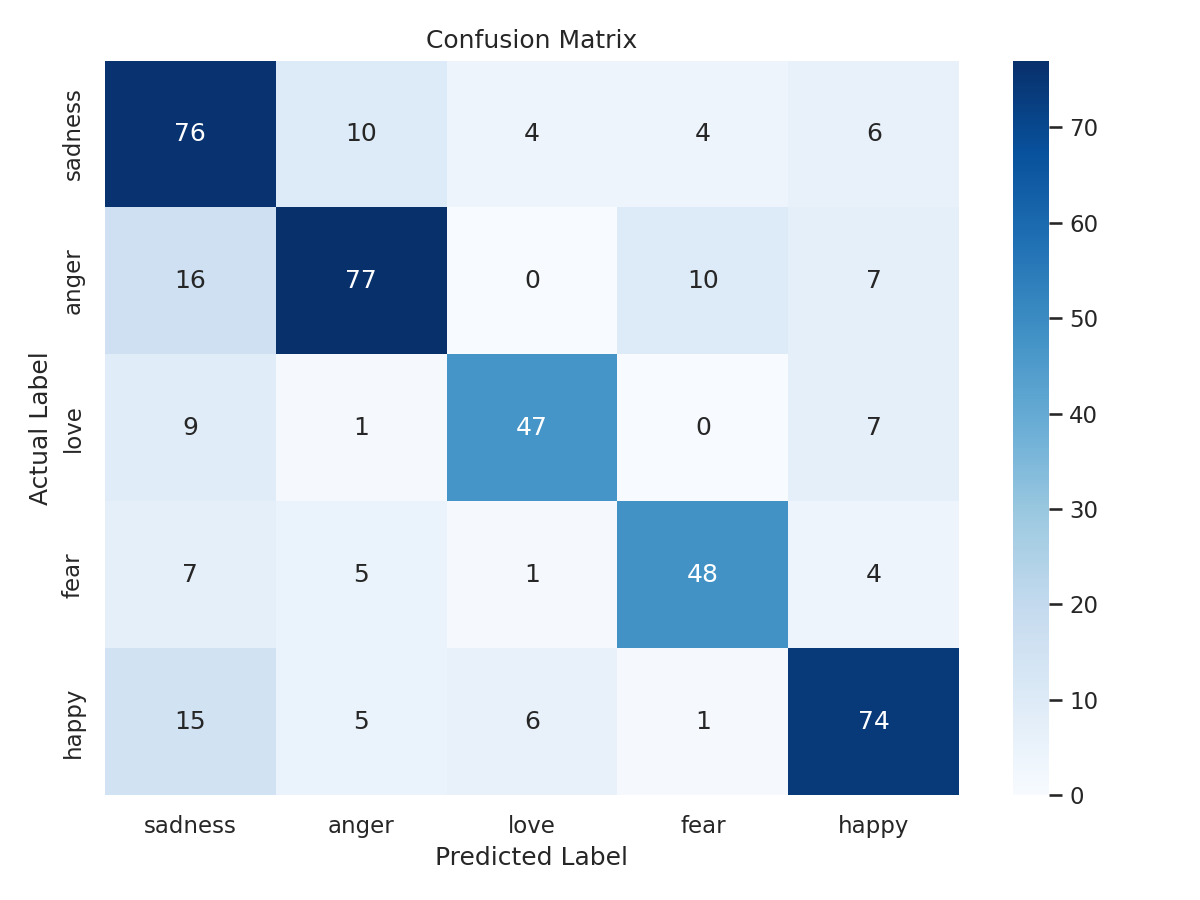

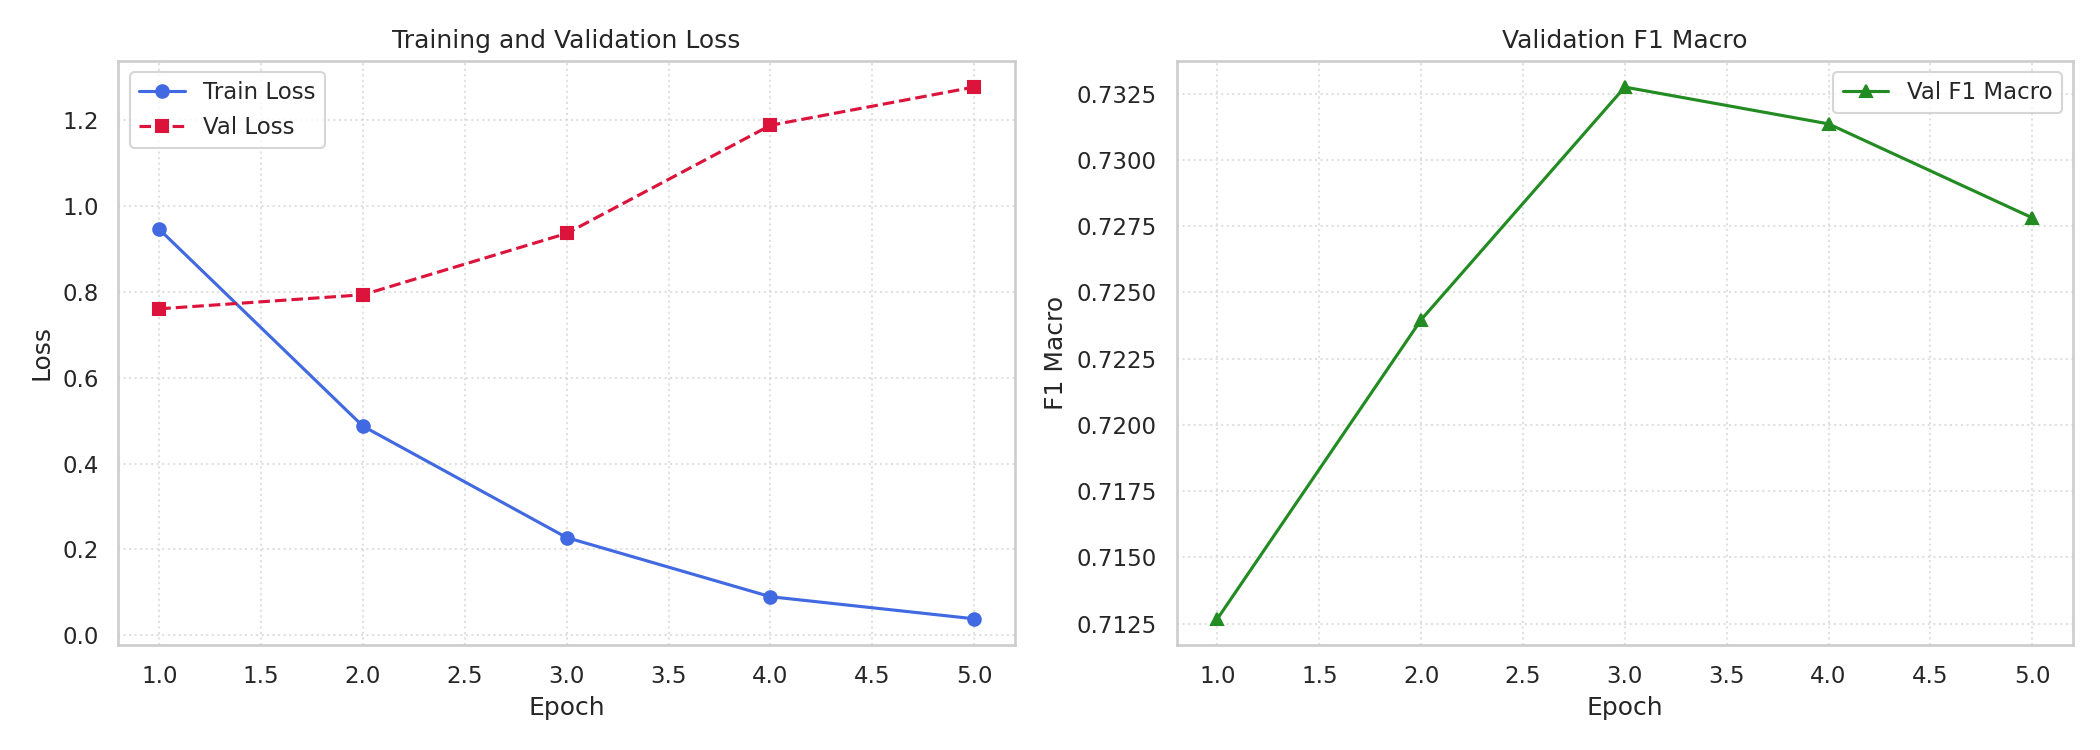

=== VISUALISASI HASIL XLM-RoBERTa ===


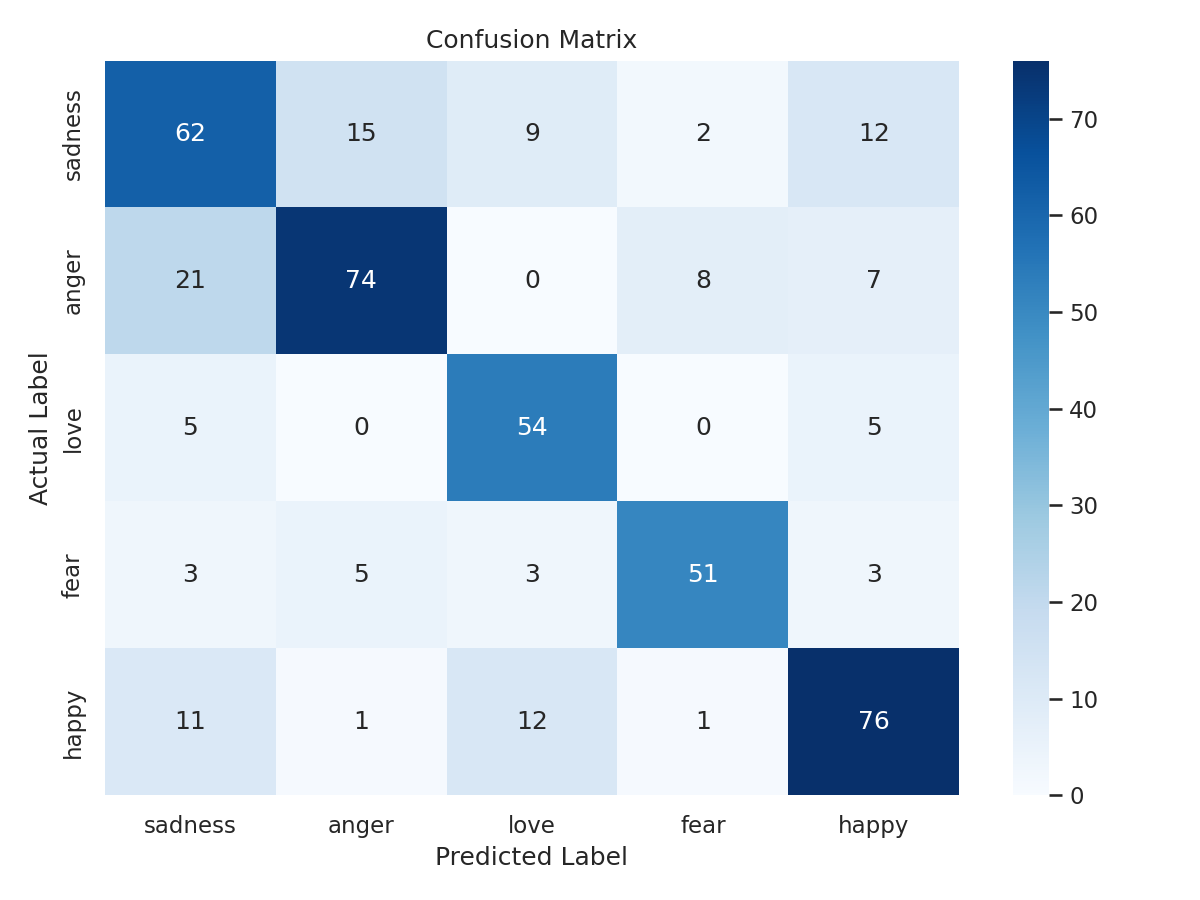

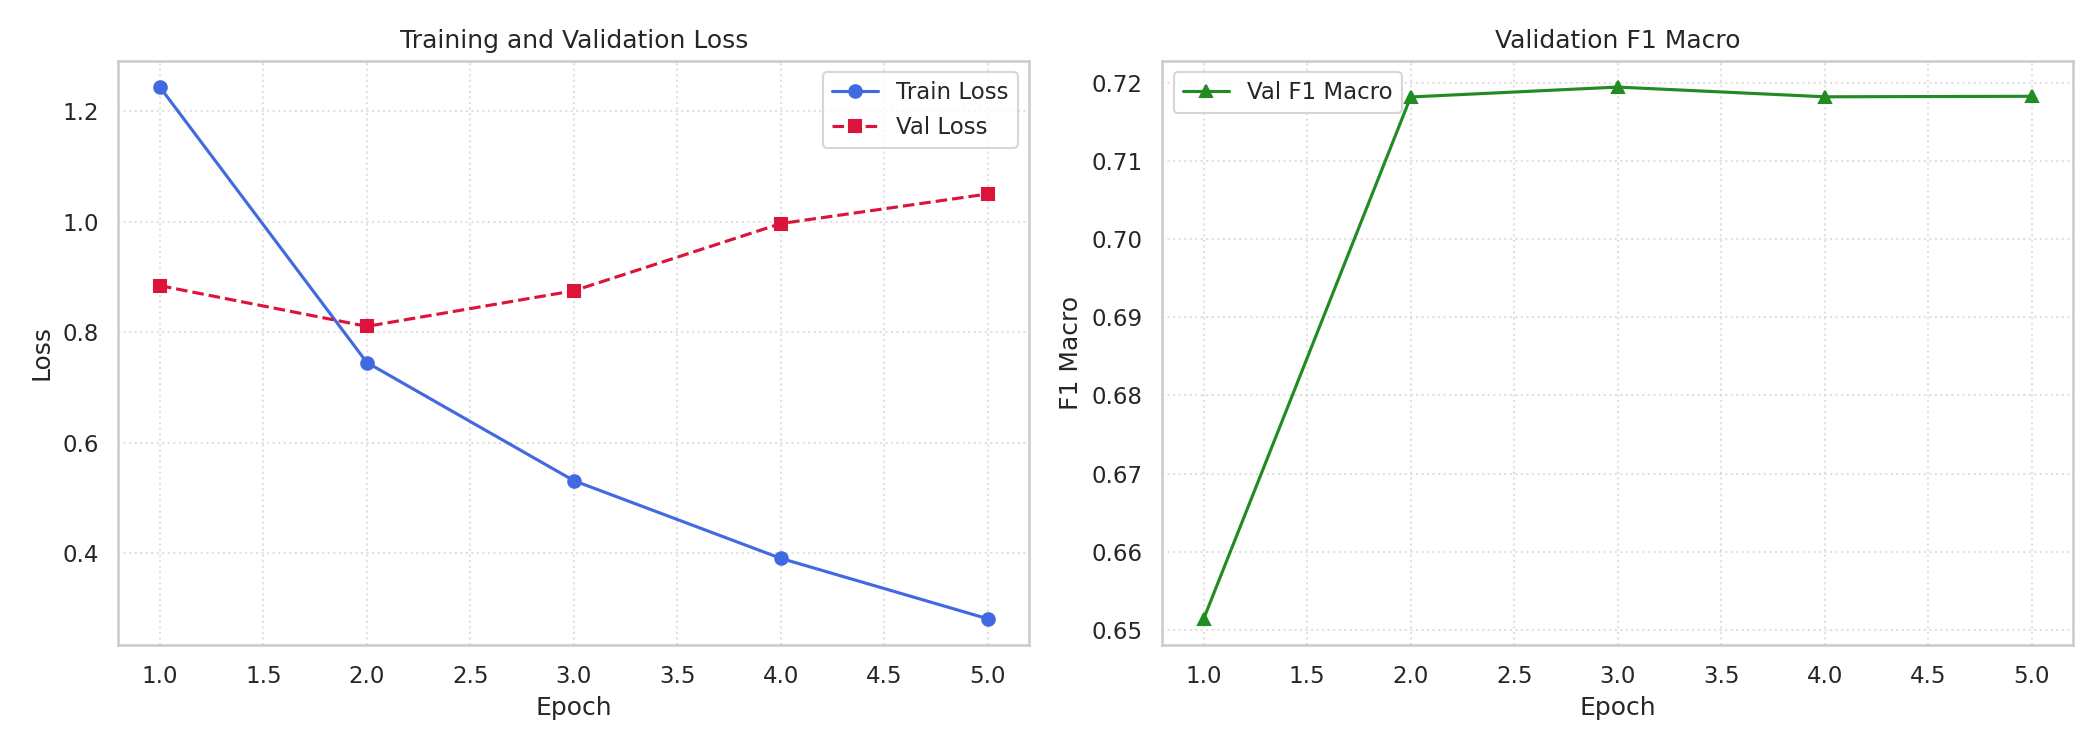

In [47]:
from IPython.display import Image, display
import os

print("=== VISUALISASI HASIL INDOBERT ===")
if os.path.exists("../results/figures/indobert_confusion_matrix.png"):
    display(Image(filename="../results/figures/indobert_confusion_matrix.png"))
    display(Image(filename="../results/figures/indobert_training_curves.png"))

print("=== VISUALISASI HASIL XLM-RoBERTa ===")
if os.path.exists("../results/figures/xlmr_confusion_matrix.png"):
    display(Image(filename="../results/figures/xlmr_confusion_matrix.png"))
    display(Image(filename="../results/figures/xlmr_training_curves.png"))